In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models 
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

In [2]:
# https://www.kaggle.com/datasets/arjuntejaswi/plant-village?resource=download

IMAGE_SIZE = 256
BATCH_SIZE = 32
RGB_CHANNELS = 3
DATA_DIR = Path.cwd().parent / 'data' / 'PlantVillage'


dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR, 
    shuffle=True, 
    image_size=(IMAGE_SIZE, IMAGE_SIZE), 
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.


In [3]:
class_names = dataset.class_names
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [4]:
# 20638 files/images divided into 32 batch size ~= 644 batches
len(dataset) 

645

In [5]:
# image_batch is a tensor of shape (32, 256, 256, 3) -> (batch_size, height, width, channels)
# label_batch is a tensor of shape (32,) -> (batch_size,)
# 15 classes in total, so label_batch contains integers from 0 to 14 representing the class indices.
for image_batch, label_batch in dataset.take(1):
    print(image_batch.shape)
    print(label_batch.numpy())


(32, 256, 256, 3)
[ 7  9  9  3  7  8  5 10 11 14 11  7  6  8 12  3  6 12  0  5  7 11 11  7
  2  5  9  5  5 11  1 12]


In [6]:
for i in dataset.take(1):
    print(i[0].shape)

(32, 256, 256, 3)


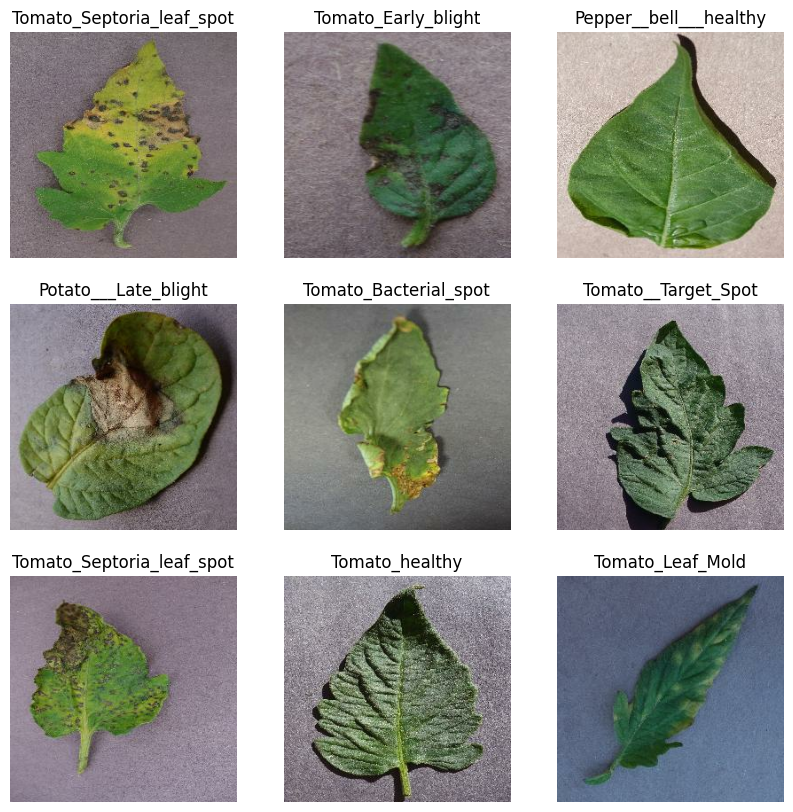

In [8]:
plt.figure(figsize=(10, 10))

for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[label_batch[i]])

# Train Test Split

In [9]:
# 80 percent training, 10 percent validation, 10 percent test
EPOCHS = 5
train_size = 0.8 

In [10]:
len(dataset) * train_size

516.0

In [11]:
train_ds = dataset.take(516)
len(train_ds)

516

In [14]:
test_validation = dataset.skip(516)
len(test_validation)

129

In [16]:
len(dataset) * .1

64.5

In [17]:
validation_ds = test_validation.take(64)
test_ds = test_validation.skip(64)

In [19]:
def get_dataset_partitions_tf(ds: tf.data.Dataset, 
                              train_split:float=0.8, 
                              val_split:float=0.1, 
                              test_split:float=0.1, 
                              shuffle:bool=True, shuffle_size:int=10000) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(ds_size * train_split)
    val_size = int(ds_size * val_split)
    test_size = int(ds_size * test_split)

    train_ds = ds.take(train_size)
    validation_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size).take(test_size)

    return train_ds, validation_ds, test_ds

In [20]:
train_ds, validation_ds, test_ds = get_dataset_partitions_tf(dataset)

In [22]:
len(train_ds), len(validation_ds), len(test_ds)

(516, 64, 64)

# Optimizing dataset with cache and prefetch

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

<_ShuffleDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

# Scaling

In [29]:
resize_rescale_pipeline = models.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), # Resize images just in case they are not already 256x256
    layers.Rescaling(1/255), # Scale RGB pixel values to 0,1
])

# Data Augmentation

In [30]:
data_augmentation_pipeline = models.Sequential([
    # Create slightly different versions of each image during training\n",
    # so the model learns features that generalize better.\n",
    layers.RandomFlip('horizontal_and_vertical'),  # Flip leaves in either direction.
    layers.RandomRotation(0.1),  # Small rotations help with camera angle variation.
    layers.RandomZoom(0.1)  # Small zoom changes help with distance/cropping variation
    
])

# CNN

In [ ]:
# Convolution and Pooling Layers -> Dense NN
model = models.Sequential([
    resize_rescale_pipeline,
    data_augmentation_pipeline,
    # filters = how many different feature patterns this layer learns to detect.
    # kernel_size = the height and width of the sliding window used to scan the image.
    layers.Conv2D(filters=32, kernel_size=(3,3), input_shape=(IMAGE_SIZE, IMAGE_SIZE, RGB_CHANNELS)),